# TP1 - Processamento Distribuído de Dados
### Raphaela Maria Costa e Silva 2020006973

# Spark Init and Imports

In [1]:
import os
import sys
sys.path.insert(0, os.path.join(os.environ["SPARK_HOME"], "python"))
sys.path.append(os.path.join(os.environ["SPARK_HOME"], "python/lib/py4j-0.10.9.7-src.zip"))

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("HelloLines") \
    .config("spark.executor.instances", "2") \
    .config("spark.executor.cores", "2") \
    .config("spark.executor.memory", "1024M") \
    .getOrCreate()
sc = spark.sparkContext

25/10/15 17:12:53 WARN Utils: Your hostname, cloud251 resolves to a loopback address: 127.0.1.1; using 192.168.121.49 instead (on interface eth0)
25/10/15 17:12:53 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/15 17:12:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/15 17:12:55 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import from_unixtime, col, year
from pyspark.sql.functions import max 
from pyspark.sql import functions as F
import pandas as pd


from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("HelloLines") \
    .config("spark.executor.instances", "2") \
    .config("spark.executor.cores", "2") \
    .config("spark.executor.memory", "1024M") \
    .getOrCreate()
sc = spark.sparkContext

# Load the Dataset


In [4]:
! hdfs dfs -ls hdfs://localhost:9000/datasets/spotify/


Found 2 items
-rw-r--r--   1 camilosm hadoop   30030481 2025-09-24 00:40 hdfs://localhost:9000/datasets/spotify/playlist.json
-rw-r--r--   1 camilosm hadoop 3159350124 2025-09-24 00:38 hdfs://localhost:9000/datasets/spotify/tracks.json


In [5]:
df_playlist = spark.read.json("hdfs://localhost:9000/datasets/spotify/playlist.json")
df_playlist.show(5) 

+-------------+-----------+-----------+-----------+----------------+----------+-----------+---------+-------------+----------+---+
|collaborative|description|duration_ms|modified_at|            name|num_albums|num_artists|num_edits|num_followers|num_tracks|pid|
+-------------+-----------+-----------+-----------+----------------+----------+-----------+---------+-------------+----------+---+
|        false|       NULL|   11532414| 1493424000|      Throwbacks|        47|         37|        6|            1|        52|  0|
|        false|       NULL|   11656470| 1506556800|Awesome Playlist|        23|         21|        5|            1|        39|  1|
|        false|       NULL|   14039958| 1505692800|         korean |        51|         31|       18|            1|        64|  2|
|        false|       NULL|   28926058| 1501027200|             mat|       107|         86|        4|            1|       126|  3|
|        false|       NULL|    4335282| 1401667200|             90s|        16|    

In [6]:
df_playlist.printSchema()

root
 |-- collaborative: string (nullable = true)
 |-- description: string (nullable = true)
 |-- duration_ms: long (nullable = true)
 |-- modified_at: long (nullable = true)
 |-- name: string (nullable = true)
 |-- num_albums: long (nullable = true)
 |-- num_artists: long (nullable = true)
 |-- num_edits: long (nullable = true)
 |-- num_followers: long (nullable = true)
 |-- num_tracks: long (nullable = true)
 |-- pid: long (nullable = true)



In [7]:
df_tracks = spark.read.json("hdfs://localhost:9000/datasets/spotify/tracks.json")
df_tracks.show(5)

+--------------------+--------------------+-----------------+--------------------+-----------+---+---+--------------------+--------------------+
|          album_name|           album_uri|      artist_name|          artist_uri|duration_ms|pid|pos|          track_name|           track_uri|
+--------------------+--------------------+-----------------+--------------------+-----------+---+---+--------------------+--------------------+
|        The Cookbook|spotify:album:6vV...|    Missy Elliott|spotify:artist:2w...|     226863|  0|  0|Lose Control (fea...|spotify:track:0Ua...|
|         In The Zone|spotify:album:0z7...|   Britney Spears|spotify:artist:26...|     198800|  0|  1|               Toxic|spotify:track:6I9...|
|Dangerously In Lo...|spotify:album:25h...|          Beyoncé|spotify:artist:6v...|     235933|  0|  2|       Crazy In Love|spotify:track:0Wq...|
|           Justified|spotify:album:6QP...|Justin Timberlake|spotify:artist:31...|     267266|  0|  3|      Rock Your Body|spotify

In [8]:
df_tracks.printSchema()

root
 |-- album_name: string (nullable = true)
 |-- album_uri: string (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- artist_uri: string (nullable = true)
 |-- duration_ms: long (nullable = true)
 |-- pid: long (nullable = true)
 |-- pos: long (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_uri: string (nullable = true)



# Statistics about songs duration

## Generate a table containing the minimum, average and maximum duration, in milliseconds, of the songs in the dataset.



### Maximum

In [9]:
def findMaxDuration(df):
    max = df.orderBy(df["duration_ms"].desc())
    maxVal = max.select("duration_ms").first()
    return maxVal

In [10]:
df_tracks_unique = df_tracks.dropDuplicates(["track_uri"])

maxVal = findMaxDuration(df_tracks_unique)
print(maxVal[0])

10435467


### Minimum

In [11]:
def findMinDuration(df):
    min = df.orderBy(df["duration_ms"].asc())
    minVal = min.select("duration_ms").first()
    return minVal

In [12]:
minVal = findMinDuration(df_tracks_unique)
print(minVal[0])

0


### Average

In [13]:
def findAverage(df):
    average = df.groupBy().avg("duration_ms")
    averageVal = average.collect()[0][0]
    return averageVal

In [14]:
averageVal = findAverage(df_tracks_unique)
print(averageVal)

243482.20965899783


### Make table

In [15]:
statistics_table = { "min_valor": [minVal[0]],
                     "media_valor": [averageVal],
                    "max_valor": [maxVal[0]]}
statistics_table = pd.DataFrame(statistics_table)

display(
    statistics_table.style
      .hide_index()
      .set_properties(**{'text-align': 'center'})
)

/tmp/ipykernel_984779/2005205968.py:8: FutureWarning: this method is deprecated in favour of `Styler.hide(axis="index")`
  .hide_index()


min_valor,media_valor,max_valor
0,243482.209659,10435467


## Compute the first and third quartiles as well as the interquartile range  


### Quartiles

In [16]:
q1,q3 = df_tracks_unique.approxQuantile("duration_ms", [0.25, 0.75], 0)
print(q1,q3)

187509.0 273333.0


### IRQ

In [17]:
IRQ = q3-q1
IRQ

85824.0

## Compute the set of songs with durations that are not outliers

In [18]:
notOutliers = df_tracks_unique.filter((df_tracks_unique["duration_ms"] > q1-1.5*IRQ) & (df_tracks_unique["duration_ms"] < q3+1.5*IRQ))

In [19]:
notOutliers.show(5)

+--------------------+--------------------+--------------+--------------------+-----------+------+---+--------------------+--------------------+
|          album_name|           album_uri|   artist_name|          artist_uri|duration_ms|   pid|pos|          track_name|           track_uri|
+--------------------+--------------------+--------------+--------------------+-----------+------+---+--------------------+--------------------+
|Harmony in Ultrav...|spotify:album:1U5...|    Tim Hecker|spotify:artist:1q...|      91826|126146| 29|   Harmony in Blue I|spotify:track:000...|
|               TajMo|spotify:album:3NF...|     Taj Mahal|spotify:artist:1a...|     160106| 26677| 17|She Knows How To ...|spotify:track:001...|
|The Greatest Song...|spotify:album:2BL...| Barry Manilow|spotify:artist:3a...|     235078| 98329| 79|(I've Had) The Ti...|spotify:track:001...|
|      Closer Remixed|spotify:album:6kD...|Tegan and Sara|spotify:artist:5e...|     274173| 11556|  2|Closer - The Knoc...|spotify

## Using the IQRR methodology, how many songs would be considered outliers and removed from analysis? Generate a new table containing the minimum, average and maximum duration of the remaining songs.

In [20]:
newMinVal = findMinDuration(notOutliers)
newMaxVal = findMaxDuration(notOutliers)
newAverage = findAverage(notOutliers)


In [21]:
new_statistics_table = { "min_valor": [newMinVal[0]],
                     "media_valor": [newAverage],
                    "max_valor": [newMaxVal[0]]}
new_statistics_table = pd.DataFrame(new_statistics_table)

display(
    new_statistics_table.style
      .hide_index()
      .set_properties(**{'text-align': 'center'})
)

/tmp/ipykernel_984779/3466427384.py:8: FutureWarning: this method is deprecated in favour of `Styler.hide(axis="index")`
  .hide_index()


min_valor,media_valor,max_valor
58775,226448.903941,402066


# 2. Finding the most popular artists over time


## Find the five most popular artists ranked by the number of playlists they appear in.

In [22]:
mostPopularArtists = (
    df_tracks.select("artist_name", "pid")
    .distinct()
    .groupBy("artist_name")
    .count()
    .orderBy("count", ascending=False)
    .limit(5)
)
top_artists_list = [row["artist_name"] for row in mostPopularArtists.collect()]
print(top_artists_list)


25/10/15 17:14:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/15 17:14:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/15 17:14:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/15 17:14:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/15 17:14:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/15 17:14:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/15 17:14:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/15 17:14:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/15 17:14:20 WARN RowBasedKeyValueBatch: Calling spill() on

['Drake', 'Rihanna', 'Kanye West', 'The Weeknd', 'Kendrick Lamar']


## Create a chart that shows the number of playlists containing each of these five artists over the years. Consider that an artist is present in a playlist after each playlist's last modification date.

In [23]:
df_with_year = df_playlist.withColumn("year", year(from_unixtime(col("modified_at"))))
df_playlist_tracks = df_with_year.join(df_tracks, on="pid")
mostPopularArtistsByYear = df_playlist_tracks.filter(F.col("artist_name").isin(top_artists_list))

In [24]:
df_playlist_tracks.printSchema()

root
 |-- pid: long (nullable = true)
 |-- collaborative: string (nullable = true)
 |-- description: string (nullable = true)
 |-- duration_ms: long (nullable = true)
 |-- modified_at: long (nullable = true)
 |-- name: string (nullable = true)
 |-- num_albums: long (nullable = true)
 |-- num_artists: long (nullable = true)
 |-- num_edits: long (nullable = true)
 |-- num_followers: long (nullable = true)
 |-- num_tracks: long (nullable = true)
 |-- year: integer (nullable = true)
 |-- album_name: string (nullable = true)
 |-- album_uri: string (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- artist_uri: string (nullable = true)
 |-- duration_ms: long (nullable = true)
 |-- pos: long (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_uri: string (nullable = true)



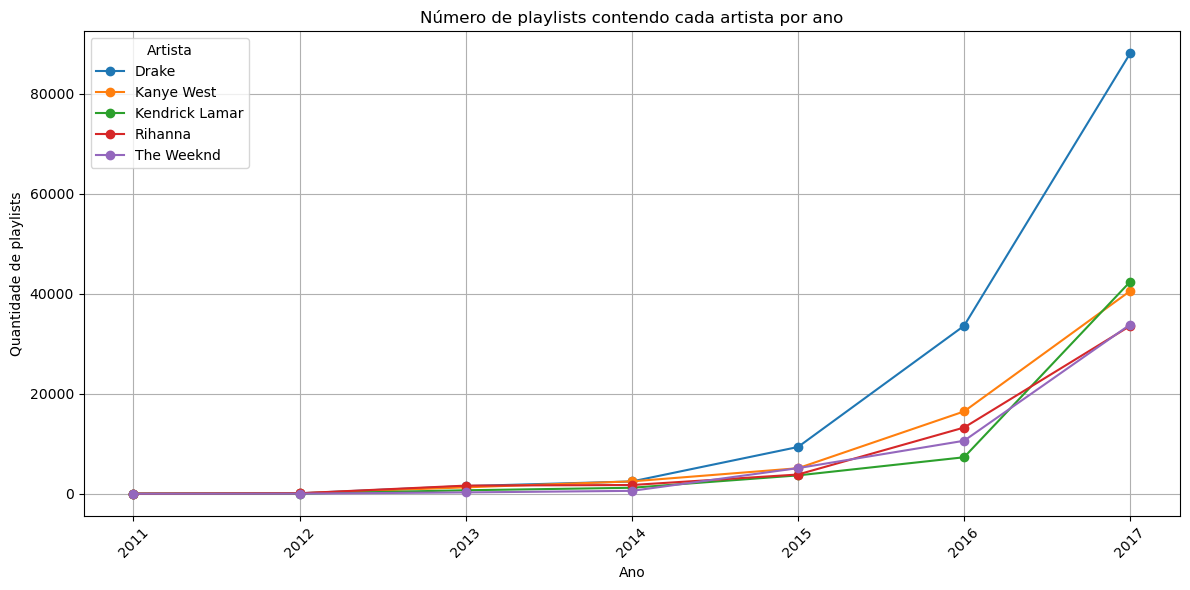

In [25]:
# Contagem e pivot
pdf = mostPopularArtistsByYear.groupBy("year", "artist_name").count().toPandas()
pdf_pivot = pdf.pivot(index='year', columns='artist_name', values='count').fillna(0)

# Gráfico de linhas
plt.figure(figsize=(12,6))

for artist in pdf_pivot.columns:
    plt.plot(pdf_pivot.index, pdf_pivot[artist], marker='o', label=artist)

plt.title("Número de playlists contendo cada artista por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de playlists")
plt.xticks(pdf_pivot.index, rotation=45)
plt.legend(title="Artista")
plt.grid(True)
plt.tight_layout()
plt.show()


# 3. Compute the prevalence of the most frequent artist in each playlist, defined as the fraction of songs by the most frequent artist. Then create a Cumulative Distribution Function (CDF) plot containing the distribution of artist prevalence across all playlists.

## For each playlist, it calculates how many songs each artist has and what fraction of the playlist those songs represent.

In [26]:
df_playlist_tracks = df_playlist.join(df_tracks, on="pid")
artist_song_count = df_playlist_tracks.groupBy("pid", "artist_name").count().withColumnRenamed("count", "artist_song_count")
num_songs_playlist = df_playlist_tracks.groupBy("pid").count().withColumnRenamed("count", "num_songs_playlist")


In [27]:
artist_song_count = artist_song_count.join(num_songs_playlist, "pid")
artist_song_count.printSchema()

root
 |-- pid: long (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- artist_song_count: long (nullable = false)
 |-- num_songs_playlist: long (nullable = false)



In [28]:
artist_song_count= artist_song_count.withColumn("fraction", artist_song_count["artist_song_count"]/artist_song_count["num_songs_playlist"])
artist_song_count.show()

+---+--------------------+-----------------+------------------+--------------------+
|pid|         artist_name|artist_song_count|num_songs_playlist|            fraction|
+---+--------------------+-----------------+------------------+--------------------+
| 26|The New Basement ...|                4|                26| 0.15384615384615385|
| 29|  Axwell /\ Ingrosso|                1|                40|               0.025|
| 29|        Bill Withers|                1|                40|               0.025|
| 29|   Chance The Rapper|                1|                40|               0.025|
| 29|                DRAM|                1|                40|               0.025|
| 29|            Maroon 5|                1|                40|               0.025|
| 29|             Ricegum|                1|                40|               0.025|
| 29|        Taylor Swift|                1|                40|               0.025|
| 29|                Zedd|                1|                40|  

## Finds the most frequent artist in each playlist, computes their fraction of songs, and plots the cumulative distribution of these fractions across all playlists.

In [29]:
artist_share = artist_song_count.withColumn(
    "fraction",
    col("artist_song_count") / col("num_songs_playlist")
)

artist_share.createOrReplaceTempView("artist_share")
most_frequent_artist = spark.sql("""
    SELECT a.pid, a.artist_name, a.fraction AS artist_prevalence
    FROM artist_share a
    JOIN (
        SELECT pid, MAX(fraction) AS max_fraction
        FROM artist_share
        GROUP BY pid
    ) b
    ON a.pid = b.pid AND a.fraction = b.max_fraction
""")
most_frequent_artist.show()

+------+-------------------+--------------------+
|   pid|        artist_name|   artist_prevalence|
+------+-------------------+--------------------+
|  7436|            Beyoncé|0.047619047619047616|
| 65840|         John Tibbs|                 0.2|
|144130|         Luke Bryan|  0.9285714285714286|
|    54|      Stevie Wonder|                 0.4|
| 91725|Two Steps from Hell| 0.35294117647058826|
|163934|       David Guetta| 0.11607142857142858|
|  7052|  Cultura Profética|  0.3958333333333333|
| 88836|  Empire of the Sun|                0.08|
| 34353|             Khalid|  0.2222222222222222|
|162557|       XXXTENTACION| 0.19230769230769232|
| 27557|        Boyz II Men| 0.08571428571428572|
|126915|    Jeremiah Clarke| 0.14285714285714285|
| 19567|          Oh Wonder|  0.2727272727272727|
|114765|         Bea Miller|0.045454545454545456|
|114765|         Erik Satie|0.045454545454545456|
|114765|      Michael Dulin|0.045454545454545456|
|168281|     Kendrick Lamar| 0.05952380952380952|


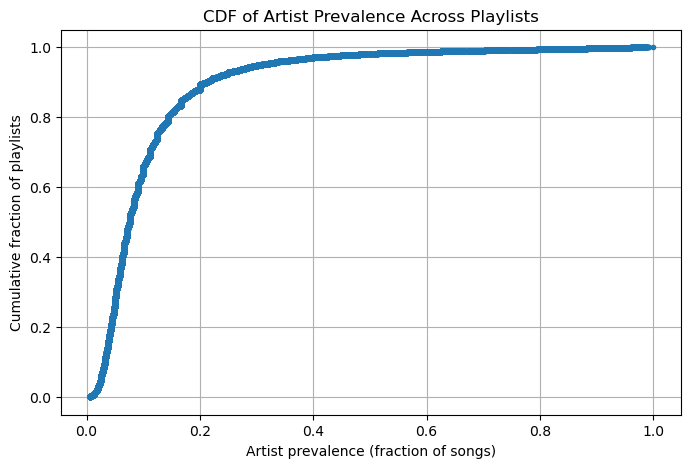

In [30]:
pdf = most_frequent_artist.toPandas()

# Ordena os valores
x = np.sort(pdf["artist_prevalence"])
y = np.arange(1, len(x)+1) / len(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, marker='.', linestyle='-')
plt.xlabel("Artist prevalence (fraction of songs)")
plt.ylabel("Cumulative fraction of playlists")
plt.title("CDF of Artist Prevalence Across Playlists")
plt.grid(True)
plt.show()
